# **Analysing the Impact of Discounts on Customer Spending Behaviour**

# Name: Nikhil Rana


#1) Imports and Setup

In [ ]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing & Selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor

# Machine Learning - Metrics
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score,
    classification_report, confusion_matrix, roc_curve, auc, silhouette_score
)

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
np.random.seed(42)

print("Libraries loaded. Ready for Advanced AI Analysis.")

Libraries loaded. Ready for Advanced AI Analysis.


#2) Data Loading and Pre-processing

In [ ]:
# Load Data which can be downloaded from following link
# https://www.kaggle.com/datasets/pratyushpuri/grocery-store-sales-dataset-in-2025-1900-record/data

df = pd.read_csv('grocery_chain_data.csv')

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   object 
 2   transaction_date  1980 non-null   object 
 3   aisle             1980 non-null   object 
 4   product_name      1980 non-null   object 
 5   quantity          1980 non-null   float64
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 170.3+ KB


,customer_id,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
count,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000
mean,5542.958081,2.968182,15.488045,45.902576,4.469591,41.432985,255.147980
std,2575.771856,1.419028,8.400823,35.018599,4.962001,32.593328,146.009333
min,1006.000000,1.000000,0.990000,1.010000,0.000000,-3.430000,0.000000
25%,3271.500000,2.000000,8.240000,18.000000,1.240000,15.800000,128.000000
50%,5582.500000,3.000000,15.190000,37.130000,3.045000,32.820000,265.500000
75%,7791.750000,4.000000,22.862500,67.930000,5.402500,60.800000,378.000000
max,9998.000000,5.000000,29.980000,149.900000,29.940000,147.910000,500.000000


In [ ]:
# --- Pre-processing ---
# Clean negatives
df_clean = df[df['final_amount'] > 0].copy()

df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1967 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1967 non-null   int64  
 1   store_name        1942 non-null   object 
 2   transaction_date  1967 non-null   object 
 3   aisle             1967 non-null   object 
 4   product_name      1967 non-null   object 
 5   quantity          1967 non-null   float64
 6   unit_price        1967 non-null   float64
 7   total_amount      1967 non-null   float64
 8   discount_amount   1967 non-null   float64
 9   final_amount      1967 non-null   float64
 10  loyalty_points    1967 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 184.4+ KB


,customer_id,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
count,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000
mean,5539.220641,2.978648,15.574936,46.187173,4.472405,41.714769,255.381291
std,2578.218502,1.416209,8.359603,34.957995,4.978023,32.515287,146.059500
min,1006.000000,1.000000,0.990000,1.020000,0.000000,0.080000,0.000000
25%,3264.500000,2.000000,8.405000,18.305000,1.220000,16.120000,128.000000
50%,5582.000000,3.000000,15.290000,37.680000,3.010000,33.400000,266.000000
75%,7793.500000,4.000000,22.915000,68.265000,5.435000,60.930000,378.000000
max,9998.000000,5.000000,29.980000,149.900000,29.940000,147.910000,500.000000


In [ ]:
# Feature Engineering
df_clean['discount_pct'] = (df_clean['discount_amount'] / df_clean['total_amount']) * 100
df_clean['discount_pct'] = df_clean['discount_pct'].fillna(0) # Handle divide by zero

# Label Encoding (Saving encoders to use them later for the 'System' part)
encoders = {}
for col in ['store_name', 'aisle', 'product_name']:
    le = LabelEncoder()
    df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col])
    encoders[col] = le

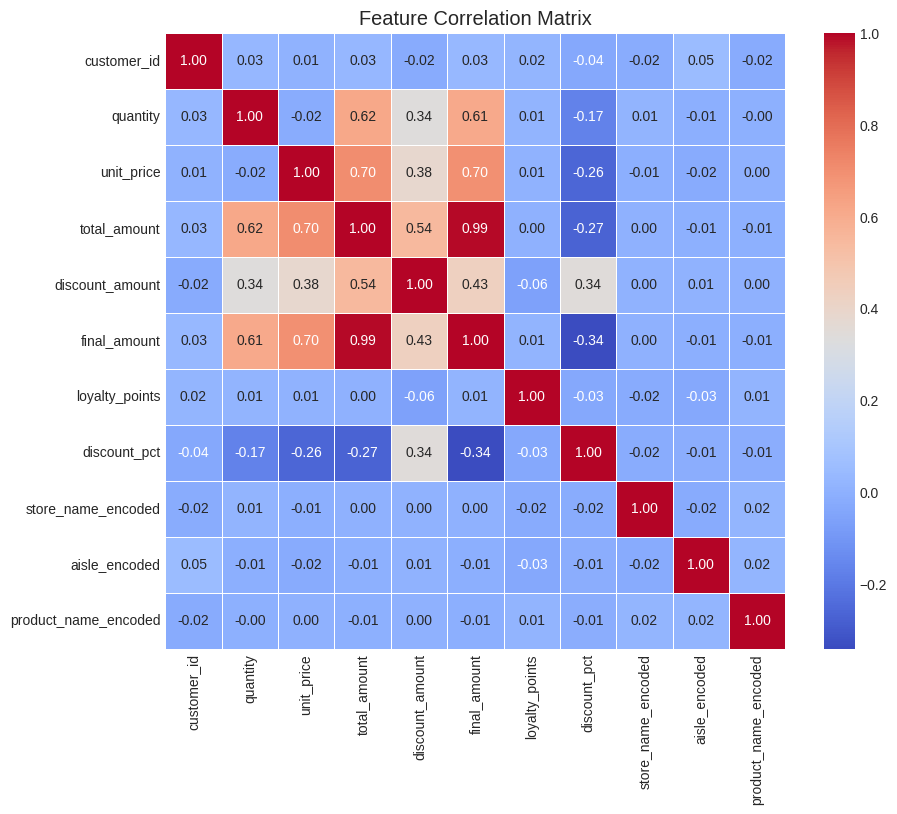

In [ ]:
# --- VISUALIZATION 1: Correlation Heatmap ---
# Shows how features relate (e.g., does loyalty correlate with final_amount?)
plt.figure(figsize=(10, 8))
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

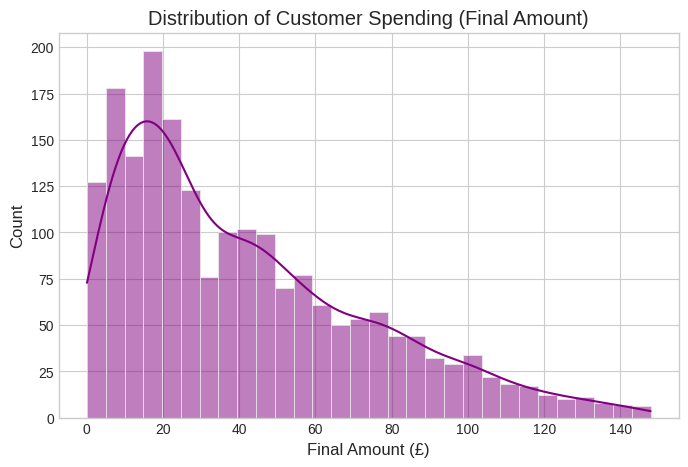

In [ ]:
# --- VISUALIZATION 2: Distribution of Spending ---
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['final_amount'], bins=30, kde=True, color='purple')
plt.title('Distribution of Customer Spending (Final Amount)')
plt.xlabel('Final Amount (£)')
plt.show()

#3) Technique 1 - Cluster Analysis (Unsupervised Learning)
Goal: Segment customers into groups (Amount of groups determined by Elbow Method) to see who uses discounts most.

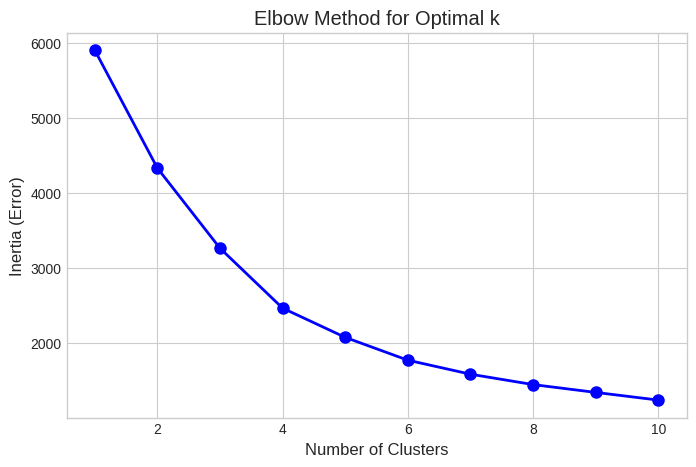

In [ ]:
# --- Clustering ---
features = ['final_amount', 'loyalty_points', 'discount_pct']
X_cluster = df_clean[features]

# Scaling is crucial for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# --- VISUALIZATION 3: The Elbow Method ---
# Calculates inertia for 1 to 10 clusters to find the optimal number
inertia = []
range_values = range(1, 11)
for i in range_values:
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range_values, inertia, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Error)')
plt.show()


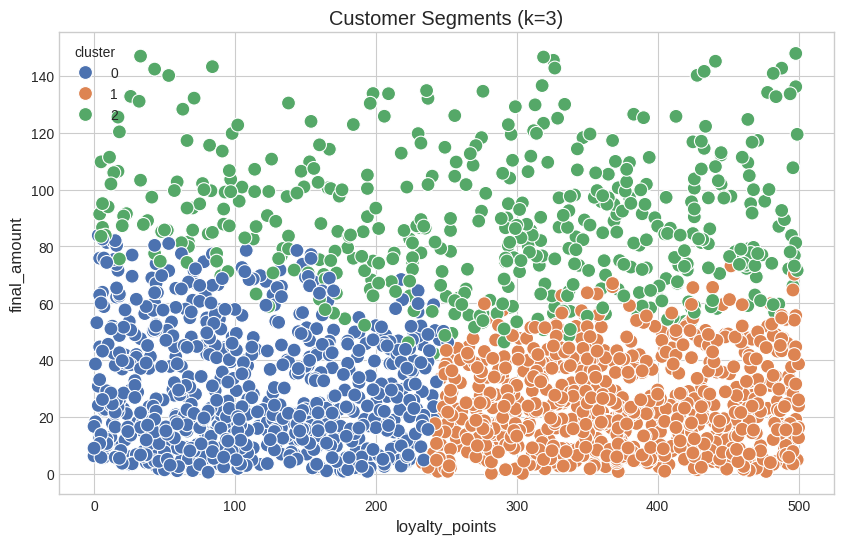

In [ ]:
# Based on the graph (usually 3 is the "elbow"), we train the final model
final_k = 3
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# --- VISUALIZATION 4: Cluster Segmentation ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='loyalty_points', y='final_amount', hue='cluster', palette='deep', s=100)
plt.title(f'Customer Segments (k={final_k})')
plt.show()

#4) Technique 2 - Supervised Learning with Tuning (Regression)
Goal: Predict the final_amount (spending) based on discount and loyalty. This proves if discounts actually drive sales.

In [ ]:
# --- Regression: Predict Final Spend ---
X = df_clean[['discount_amount', 'loyalty_points', 'quantity', 'aisle_encoded']]
y = df_clean['final_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Linear Regression (Baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Model 2: Random Forest (Advanced - handles non-linear relationships)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Linear Regression R2: {r2_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf):.4f}")

Linear Regression R2: 0.4018
Random Forest R2: 0.3840


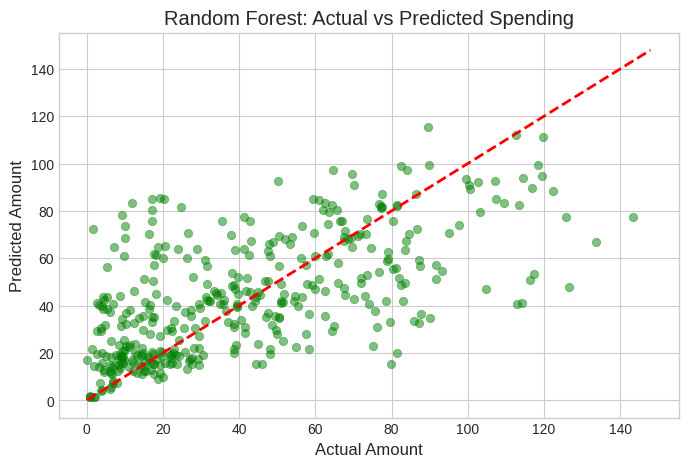

In [ ]:
# --- VISUALIZATION 5: Actual vs Predicted (Residuals) ---
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Amount')
plt.ylabel('Predicted Amount')
plt.title('Random Forest: Actual vs Predicted Spending')
plt.show()

#5) Technique 3 - Classification with ROC Curve

Goal: segregate "Discount Sensitive" customers.

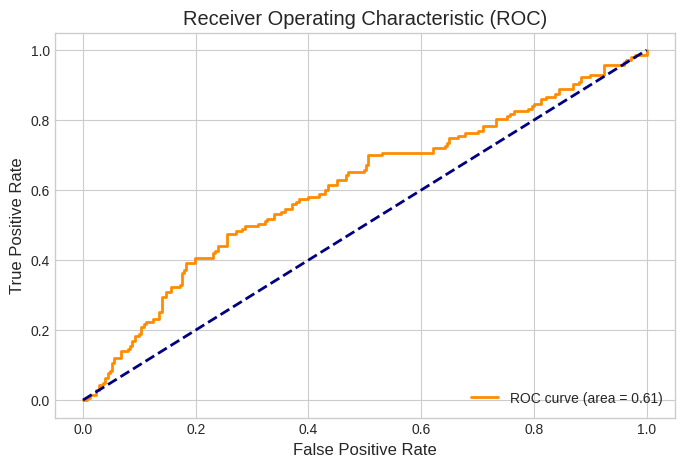

In [ ]:
# Threshold: 15% discount
df_clean['high_discount_user'] = (df_clean['discount_pct'] > 15).astype(int)

X_cls = df_clean[['loyalty_points', 'total_amount', 'aisle_encoded']]
y_cls = df_clean['high_discount_user']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(X_train_c, y_train_c)
y_prob = clf.predict_proba(X_test_c)[:, 1] # Probability for ROC curve

# --- VISUALIZATION 6: ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

#6) The "Working System" (Inference Engine)
This is the unique part that answers "can we add a row and predict". This function acts as a deployed AI system where we can segment a transaction to cluter groups, discount hunters, and predict final amount spending.

In [ ]:
def grocery_ai_system(new_data):
    """
    Accepts a dictionary of new transaction data and returns:
    1. Predicted Cluster (Segment)
    2. Predicted Spending (Regression)
    3. Discount Sensitivity (Classification)
    """
    # 1. Convert Dictionary to DataFrame
    input_df = pd.DataFrame([new_data])

    # 2. Encode categorical strings (handle unseen labels gracefully)
    for col, encoder in encoders.items():
        if col in input_df.columns:
            # Use a safe method to handle unseen labels (assign to 0 if unknown)
            input_df[f'{col}_encoded'] = input_df[col].apply(lambda x: encoder.transform([x])[0] if x in encoder.classes_ else 0)

    # 3. Feature Engineering for Inference
    # Note: We need to calculate discount_pct if not provided, or assume it based on input
    input_df['discount_pct'] = (input_df['discount_amount'] / input_df['total_amount']) * 100

    # --- Run Predictions ---

    # A. Cluster Prediction
    # We must scale the input using the SAME scaler from training
    cluster_cols = ['final_amount', 'loyalty_points', 'discount_pct']
    # Ensure final_amount is present (or predict it first if this was a real live system. Here we assume we have historical data for the row)
    X_new_cluster = scaler.transform(input_df[cluster_cols])
    predicted_cluster = kmeans.predict(X_new_cluster)[0]

    # B. Spending Prediction (Regression)
    reg_cols = ['discount_amount', 'loyalty_points', 'quantity', 'aisle_encoded']
    predicted_spend = rf.predict(input_df[reg_cols])[0]

    # C. High Discount Probability
    cls_cols = ['loyalty_points', 'total_amount', 'aisle_encoded']
    discount_prob = clf.predict_proba(input_df[cls_cols])[0][1]

    # Output Results
    print("--- AI System Output ---")
    print(f"Input Customer: {new_data['loyalty_points']} points, Buying: {new_data['product_name']}")
    print(f"1. Customer Segment: Cluster {predicted_cluster}")
    print(f"2. Predicted Final Spend: £{predicted_spend:.2f}")
    print(f"3. Likelihood of being a 'Discount Hunter': {discount_prob*100:.1f}%")
    print("------------------------")

In [ ]:
# --- TEST THE SYSTEM (Adding a "New Row") ---
new_customer_row = {
    'store_name': 'GreenGrocer Plaza',
    'aisle': 'Dairy',
    'product_name': 'Cheese',
    'quantity': 2,
    'total_amount': 20.00,
    'discount_amount': 5.00, # 25% discount
    'final_amount': 15.00,   # Usually known after purchase, used here for clustering
    'loyalty_points': 600    # High loyalty
}

grocery_ai_system(new_customer_row)

--- AI System Output ---
Input Customer: 600 points, Buying: Cheese
1. Customer Segment: Cluster 1
2. Predicted Final Spend: £24.47
3. Likelihood of being a 'Discount Hunter': 36.0%
------------------------
